<a href="https://colab.research.google.com/github/garvjain7/ai-ml-deeplearning-masterclass/blob/main/Day2_Deep_Networks_Masterclass.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎓 Day 2 Masterclass — 2nd April 2026
# Training Deep Networks: Optimisers, Initialisation & Regularisation

---

## 🩺 Our Dataset: Breast Cancer Wisconsin

**What is the task?**  
Given measurements of a tumour (size, shape, texture), predict: **Malignant (cancerous)** or **Benign (harmless)**?

**Why this dataset?**
- Real medical data — meaningful stakes!
- 569 patients, 30 features each
- Binary classification — perfect for a neural network

---

## 🧠 Today's Big Questions

| Topic | Analogy |
|---|---|
| **Optimiser** | *How fast & smart do we walk downhill?* |
| **Initialisation** | *Where do we start the walk?* |
| **Regularisation** | *How do we stop memorising instead of learning?* |

---

> ⏱️ **Session time: ~1.5 hours** | No prior Python knowledge needed!

---
## 📦 STEP 1 — Load Our Tools & Data

> **Analogy:** Before cooking, you gather your ingredients and kitchen tools. This cell imports everything we need.

**Simple** Real-Life Analogy
Suppose you are setting up a lab:

numpy → calculator;
matplotlib → whiteboard;
dataset → experiment data;
scaler → measuring tool;
model → brain;
metrics → result checking.

In [ ]:
# ── Import the libraries (our toolbox) ──────────────────────────────────────

import numpy as np
# Used for numerical operations (arrays, calculations) → "Calculator of ML"

import matplotlib.pyplot as plt
# Used for plotting graphs → "Visualization tool"

from sklearn.datasets import load_breast_cancer
# Loads a pre-built dataset (breast cancer data) → "Ready-made dataset"
#Focus = Model Learning, not Data Collection.

from sklearn.model_selection import train_test_split
# Splits data into training and testing sets → "Train vs Test"

from sklearn.preprocessing import StandardScaler
# Scales data to same range → "Normalize values" to evaluate all at same value or lable

from sklearn.neural_network import MLPClassifier
# Neural Network model (Multi-Layer Perceptron) → "Brain of the system"

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
# Used to evaluate model performance:
# accuracy → overall correctness
# confusion_matrix → detailed prediction results
# classification_report → precision, recall, F1-score

import warnings
# Used to manage warning messages

warnings.filterwarnings('ignore')
# Ignore warnings → "Clean output"

print('✅ All tools loaded successfully!')
# Confirmation message → "Everything is ready"

✅ All tools loaded successfully!


In [ ]:
# ── Load the Breast Cancer dataset ──────────────────────────────────────────

data = load_breast_cancer()
# Load pre-built dataset → contains features + labels data is object where all info of dataset is stored

# ── Separate input (X) and output (y) ───────────────────────────────────────

X = data.data
# X is Input features → 30 measurements for each patient ex. Cell, Size, Shape

y = data.target
# Target labels → 0 = Malignant, 1 = Benign

# ── Basic dataset information ──────────────────────────────────────────────

print(f'📊 Dataset shape : {X.shape}')
# Shows (number of samples, number of features) 569 patients, 30 features

print(f'🔴 Malignant (0) : {(y==0).sum()} patients')
# Count how many patients have malignant cancer

print(f'🟢 Benign   (1) : {(y==1).sum()} patients')
# Count how many patients have benign cancer y==1 checking how many 0 are there.. sum()total count

# ── Display feature names ──────────────────────────────────────────────────

print(f'\n📋 Feature names (first 5):')
# Print only first 5 feature names (for simplicity)

for name in data.feature_names[:5]:
    print(f'   • {name}')
    #Loop is for print one by one top 5 features.

📊 Dataset shape : (569, 30)
🔴 Malignant (0) : 212 patients
🟢 Benign   (1) : 357 patients

📋 Feature names (first 5):
   • mean radius
   • mean texture
   • mean perimeter
   • mean area
   • mean smoothness


---
## 🔪 STEP 2 — Split Data into Train & Test

> **Analogy:** A medical student learns from past patient records (training set), then is tested on NEW patients they've never seen (test set). We do the same here.
>
> **Rule of thumb:** 80% train, 20% test.

In [ ]:
# ── Split: 80% training, 20% testing ────────────────────────────────────────

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    # 20% data used for testing, 80% for training

    random_state=42
    # Fixed value to get the same split every time (reproducibility)
)

# ── Print dataset sizes ─────────────────────────────────────────────────────

print(f'🏋️  Training samples : {X_train.shape[0]}')
# Number of samples used to train the model

print(f'🧪 Testing  samples : {X_test.shape[0]}')
# Number of samples used to test the model

🏋️  Training samples : 455
🧪 Testing  samples : 114


---
## ⚖️ STEP 3 — Scaling (Normalisation)

> **Analogy:** Imagine comparing weights (kg) with heights (cm). A neural network gets confused by very different number ranges. Scaling makes everything play nicely on the same field — like converting all scores to a 0–10 scale.

**Why it matters:** Without scaling, big-number features dominate and the network learns badly.

In [ ]:
# ── StandardScaler: makes mean=0, std=1 for every feature ───────────────────
#Scaling ensures fair learning by bringing all features to the same scale.
scaler = StandardScaler()
# Create scaler → used to normalize data
#like if theory marks is out of 100 and practical is out of 50 so we can't Compare
#first need to make a range after that we can normalize
# ── Fit on training data and transform ─────────────────────────────────────

X_train_scaled = scaler.fit_transform(X_train)
# fit → learn mean & standard deviation from training data
# transform → apply scaling
#Fit means Model is learning from the data(Mean & Std) and transform means scaling of data
# Fit() deals with only training data and transform deals with test data.

# ── Apply same transformation to test data ──────────────────────────────────

X_test_scaled = scaler.transform(X_test)
# Only transform test data (DO NOT fit again → avoids data leakage)

# ── Compare before and after scaling ───────────────────────────────────────

print('BEFORE scaling — first feature (mean radius):')
print(f'  Min={X_train[:,0].min():.2f},  Max={X_train[:,0].max():.2f}')
# Original range means to check theory 100 and practical 50
# break this line into four parts: Print for output on screen
#f'...' it is a string in which now we can store the variable into this string.
#X_train[:,0] this is for indexing as we are selecting a specific column of data : all rows, 0 first column.
#.min() → smallest value .max() → largest value pointing minimum and maximum value of column.
#.2 → 2 decimal places, f → float number x = 3.14159 output= 3.14
#We are taking first feature's min and max value to print from training data formatted to 2 decimal places.


print('\nAFTER scaling:')
print(f'  Min={X_train_scaled[:,0].min():.2f},  Max={X_train_scaled[:,0].max():.2f}')
# Scaled range value is now minimum and in same range to use

print(f'  Mean={X_train_scaled[:,0].mean():.2f} (approx 0) ✅')
# Mean becomes ~0 after scaling means scaling is successful now.

BEFORE scaling — first feature (mean radius):
  Min=7.69,  Max=28.11

AFTER scaling:
  Min=-1.82,  Max=3.96
  Mean=-0.00 (approx 0) ✅


---
## 🏔️ STEP 4 — Understanding Optimisers
We have seen untill now that how model is learning now we will analyse in which speed model is learning?

> **The Big Analogy: Hiking Down a Mountain in Fog** 🌫️
>
> Imagine you're on a mountain and want to reach the lowest valley (= minimum error). You can't see far. You take steps downhill. The **optimiser** decides *how big* each step is and *which direction* to go.

>
> | Optimiser | Analogy | Behaviour |
> |---|---|---|
> | **SGD**  (Stochastic Gradient Descent)| Walking carefully, small steps,Slow but predictable |Stable |
> | **SGD + Momentum** | Rolling a snowball downhill | Builds speed, can overshoot, memorise past experience. |
> | **Adam** | Smart GPS navigator | Fast, adapts step size per direction, It adjust itself best example map nevigator it tooks different steps in different paths |

| Optimizer | Speed  | Smartness | Use Case        |
| --------- | ------ | --------- | --------------- |
| SGD       | Slow   | Low       | Basics          |
| Momentum  | Medium | Medium    | Faster learning |
| Adam      | Fast   | High      | Most used 🔥    |

Optimizer decides HOW to learn
Yesterday we saw backpropagation — error found
Today optimizer decide — How to solve and fix the error.
Optimizer controls how fast and how smart the model learns.
We'll compare SGD vs Adam on our cancer dataset.

In [ ]:
# ── Compare Optimisers ───────────────────────────────────────────────────────
# We train 3 small networks, same architecture, different optimisers

results = {}  # store accuracy for each

# ---- 1. SGD (vanilla) -------------------------------------------------------
sgd_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),  # 2 hidden layers
    solver='sgd',                  # Stochastic Gradient Descent
    learning_rate_init=0.01,
    max_iter=200,
    random_state=42
)
sgd_model.fit(X_train_scaled, y_train)
results['SGD'] = accuracy_score(y_test, sgd_model.predict(X_test_scaled))
print(f'🐢 SGD Accuracy         : {results["SGD"]*100:.1f}%')

# ---- 2. SGD with Momentum ---------------------------------------------------
mom_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    solver='sgd',
    momentum=0.9,                  # adds momentum (snowball effect)
    learning_rate_init=0.01,
    max_iter=200,
    random_state=42
)
mom_model.fit(X_train_scaled, y_train)
results['SGD+Momentum'] = accuracy_score(y_test, mom_model.predict(X_test_scaled))
print(f'⚡ SGD+Momentum Accuracy : {results["SGD+Momentum"]*100:.1f}%')

# ---- 3. Adam ----------------------------------------------------------------
adam_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    solver='adam',                 # Adaptive Moment Estimation
    learning_rate_init=0.001,
    max_iter=200,
    random_state=42
)
adam_model.fit(X_train_scaled, y_train)
results['Adam'] = accuracy_score(y_test, adam_model.predict(X_test_scaled))
print(f'🚀 Adam Accuracy         : {results["Adam"]*100:.1f}%')

🐢 SGD Accuracy         : 97.4%
⚡ SGD+Momentum Accuracy : 97.4%
🚀 Adam Accuracy         : 97.4%


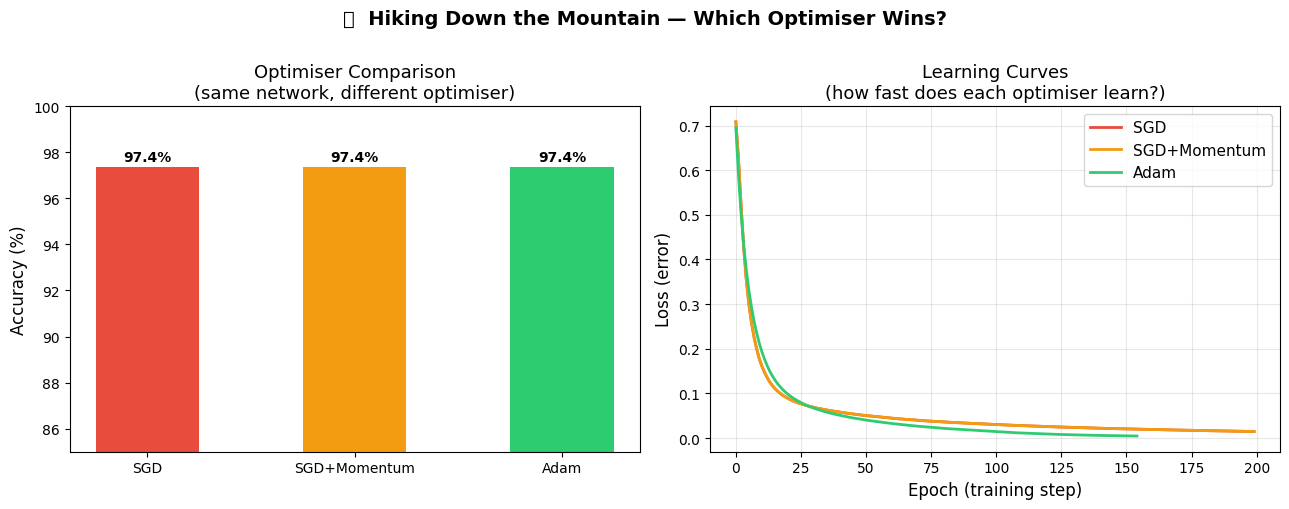


💡 KEY INSIGHT: Adam usually converges faster and reaches lower loss!


In [ ]:
# ── Plot: Optimiser Comparison ───────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
# Create 2 plots side by side Left → Accuracy Right → Learning curve


# ── Bar chart: Accuracy comparison ──────────────────────────────────────────

colors = ['#e74c3c', '#f39c12', '#2ecc71']
# Colors for each optimizer

bars = axes[0].bar(
    results.keys(),
    [v*100 for v in results.values()],
    color=colors,
    width=0.5
)
# Plot accuracy (converted to percentage)
#axes[0].bar bars that Comapres each optimizers accuracy
#v*100 for v in results.values() convert accuracy to percentage


axes[0].set_ylabel('Accuracy (%)', fontsize=12)
axes[0].set_title('Optimiser Comparison\n(same network, different optimiser)', fontsize=13)
axes[0].set_ylim(85, 100)
# Set y-axis range

# Add value labels on top of bars
for bar, val in zip(bars, results.values()): # Graph,s columns (rectangles); results.values()Accuracy values (numbers)
# zip() pair both list in one; With each bars it pairs its values and execute the loop.
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.1,
        f'{val*100:.1f}%',
        ha='center',
        va='bottom',
        fontweight='bold'
    )
#axes[0].text(...) To write the text on graph
#bar.get_x() →  X Position where to write text horizontalbar's starting point; bar.get_width() → bar's width; width/2 → center
#bar.get_height() + 0.1 for vertical height
#  f'{val*100:.1f}%' Shows exact accuracy on each bars to show clearly which optimizer is working best.
#val → 0.91; val * 100 → 91; :.1f → 1 decimal Change value into percentage

# We are placing formatted accuracy values exactly at the top-center of each bar.

# ── Line plot: Loss curves ──────────────────────────────────────────────────

for model, label, color in [
    (sgd_model, 'SGD', '#e74c3c'),
    (mom_model, 'SGD+Momentum', '#f39c12'),
    (adam_model, 'Adam', '#2ecc71')
]:
    axes[1].plot(model.loss_curve_, label=label, color=color, linewidth=2)
# Plot how loss decreases over training

axes[1].set_xlabel('Epoch (training step)', fontsize=12)
axes[1].set_ylabel('Loss (error)', fontsize=12)
axes[1].set_title('Learning Curves\n(how fast does each optimiser learn?)', fontsize=13)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

# ── Final layout ────────────────────────────────────────────────────────────

plt.suptitle('🏔️  Hiking Down the Mountain — Which Optimiser Wins?',
             fontsize=14, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig('optimiser_comparison.png', dpi=120, bbox_inches='tight')
# Save the plot as image

plt.show()

print('\n💡 KEY INSIGHT: Adam usually converges faster and reaches lower loss!')

---
## 🌱 STEP 5 — Initialisation: Where Learning actually starts Do We Start?

> **Analogy: Planting Seeds** 🌱
>
> If you plant seeds (initial weights) in the wrong place (e.g., all zeros/All seed we bow at a place only, or too large), the plant (network) never grows well. Good initialisation gives the network a **healthy head start**. Seeds(Weight) Plant's Growth (Learning)
| Init Type    | Problem               |
| ------------ | --------------------- |
| Zeros        | No learning           |
| Random Large | Exploding / Vanishing |
| Xavier / He  | Stable learning ✅     |

Initialization main goal: “To stable Gradient across layers”
Good initialization ensures that learning starts properly and gradients flow smoothly.
"Deep networks me initialization galat ho gaya toh training fail ho jaati hai"

>
> | Init Strategy | Analogy | Problem it Solves |
> |---|---|---|
> | **All Zeros** | All seeds in same spot | Neurons learn identically — useless! |
> | **Random (large)** | Seeds scattered too far | Signals explode or vanish |
> | **Xavier / He** | Seeds spaced just right | Gradients flow nicely through layers |

sklearn uses **He initialisation** by default — let's observe the effect with a mini experiment.
"Ab hum dekhte hain ki different initialization me weights ka distribution kaisa hota hai"

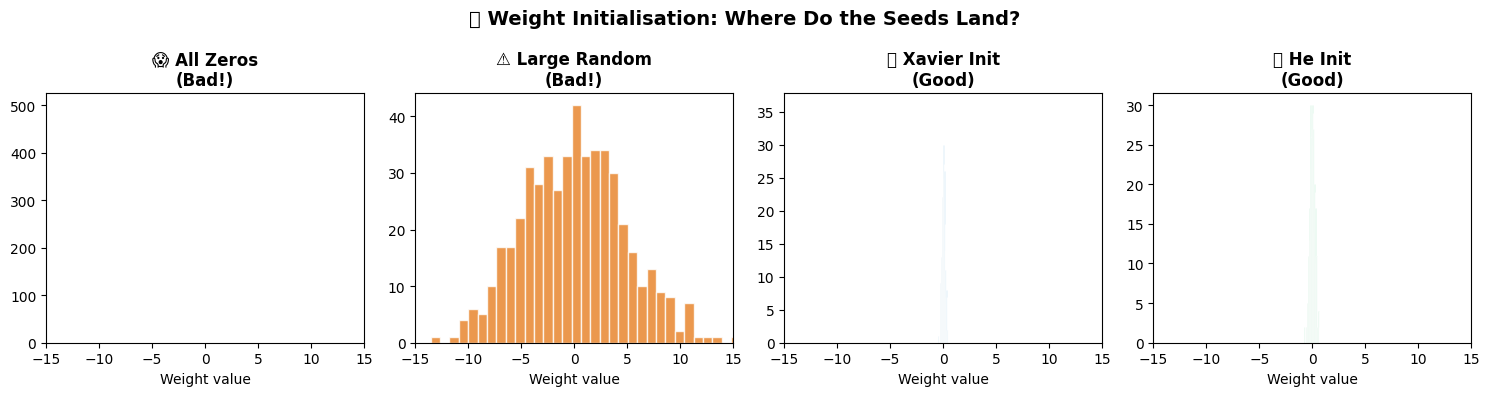


💡 KEY INSIGHT:
   • All zeros → all neurons are identical → network cannot learn different features
   • Too large  → signals explode through layers
   • Xavier/He  → signals flow smoothly → network learns efficiently


In [ ]:
# ── Visualise Weight Initialisation Distributions ────────────────────────────
np.random.seed(42)
n_neurons = 500 # We are generating 500 neurons weights with fix seed so to get same output

# Different init strategies
zeros_init  = np.zeros(n_neurons)                        # All zero (bad!) every weight is zero here graph will be streight line and identical where no learning happens.
random_init = np.random.randn(n_neurons) * 5             # Large random (bad!) random values with large entity graph Values more spread out (−15 se +15) ; Signals explode
xavier_init = np.random.randn(n_neurons) * np.sqrt(1/30) # Xavier (good!) Stable at centre 0
he_init     = np.random.randn(n_neurons) * np.sqrt(2/30) # He     (good!) For ReLU optimized initialization graph will be Better gradient flow for deep networks

fig, axes = plt.subplots(1, 4, figsize=(15, 4))

configs = [
    (zeros_init,  'All Zeros\n(Bad!)',  '#e74c3c', '😱'),
    (random_init, 'Large Random\n(Bad!)', '#e67e22', '⚠️'),
    (xavier_init, 'Xavier Init\n(Good)', '#3498db', '✅'),
    (he_init,     'He Init\n(Good)',    '#2ecc71', '🌟'),
]

for ax, (data_init, title, color, emoji) in zip(axes, configs):
    ax.hist(data_init, bins=40, color=color, alpha=0.8, edgecolor='white')
    ax.set_title(f'{emoji} {title}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Weight value', fontsize=10)
    ax.set_xlim(-15, 15)

plt.suptitle('🌱 Weight Initialisation: Where Do the Seeds Land?',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('init_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

print('\n💡 KEY INSIGHT:')
print('   • All zeros → all neurons are identical → network cannot learn different features')
print('   • Too large  → signals explode through layers')
print('   • Xavier/He  → signals flow smoothly → network learns efficiently')

---
## 🛡️ STEP 6 — Regularisation: Stop Memorising, Start Learning!

> **Analogy: The Exam Student** 📚
>
> A bad student **memorises** every practice question (overfitting) but fails on new questions. A good student **understands the concepts** and can answer anything new (generalisation).
Overfitting = model memorises training data but fails on new data.

**“Day 1 me humne learning samjhi
Day 2 me hum learning ko control karna seekh rahe hain”**

>
> Regularisation is the teacher saying: *"Don't just memorise — understand!"*
>
> | Technique | What it does | Analogy |
> |---|---|---|
> | **L2 (weight decay)** | Penalises large weights | Telling student: don't over-rely on one fact |
> | **Dropout** | Randomly switches off neurons during training | Student studies without notes sometimes |
> | **Early stopping** | Stop training before overfitting | Stop practising when you're ready |

Let's see overfitting vs regularisation on our cancer data.

In [ ]:
# ── Overfitting vs Regularisation ────────────────────────────────────────────
from sklearn.neural_network import MLPClassifier

# Model 1: BIG network, NO regularisation → likely to overfit
overfit_model = MLPClassifier(
    hidden_layer_sizes=(200, 200, 200),   # very large
    alpha=0.00001,                         # very small L2 penalty (almost none)
    solver='adam',
    max_iter=500,
    random_state=42
)
overfit_model.fit(X_train_scaled, y_train)
ov_train = accuracy_score(y_train, overfit_model.predict(X_train_scaled))
ov_test  = accuracy_score(y_test,  overfit_model.predict(X_test_scaled))
print('🔴 No Regularisation (Overfit Risk):')
print(f'   Train accuracy: {ov_train*100:.1f}%')
print(f'   Test  accuracy: {ov_test*100:.1f}%')
print(f'   Gap (overfit?): {(ov_train - ov_test)*100:.1f}%  ← bigger gap = more overfitting')

print()

# Model 2: Same network, WITH L2 regularisation
reg_model = MLPClassifier(
    hidden_layer_sizes=(200, 200, 200),
    alpha=0.1,                             # stronger L2 penalty
    solver='adam',
    max_iter=500,
    random_state=42
)
reg_model.fit(X_train_scaled, y_train)
rg_train = accuracy_score(y_train, reg_model.predict(X_train_scaled))
rg_test  = accuracy_score(y_test,  reg_model.predict(X_test_scaled))
print('🟢 With L2 Regularisation:')
print(f'   Train accuracy: {rg_train*100:.1f}%')
print(f'   Test  accuracy: {rg_test*100:.1f}%')
print(f'   Gap (overfit?): {(rg_train - rg_test)*100:.1f}%  ← smaller gap = better generalisation')

🔴 No Regularisation (Overfit Risk):
   Train accuracy: 100.0%
   Test  accuracy: 96.5%
   Gap (overfit?): 3.5%  ← bigger gap = more overfitting

🟢 With L2 Regularisation:
   Train accuracy: 100.0%
   Test  accuracy: 96.5%
   Gap (overfit?): 3.5%  ← smaller gap = better generalisation


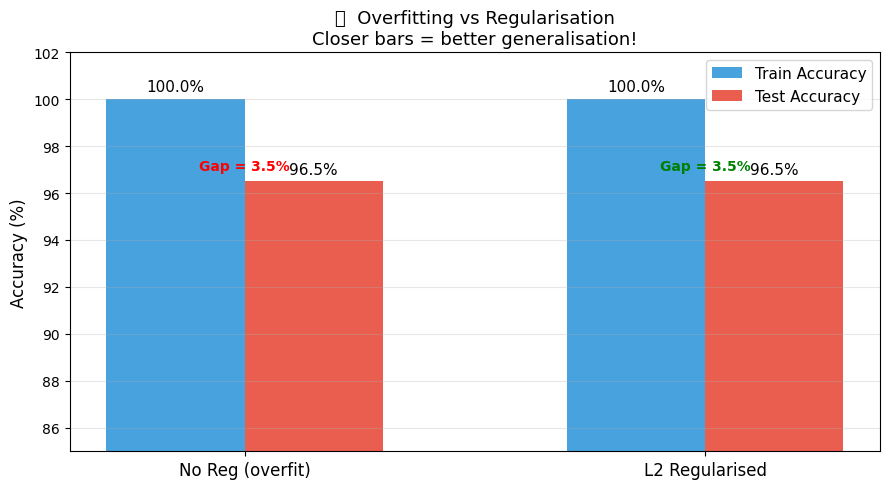

In [ ]:
# ── Visualise Overfitting vs Regularisation ───────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

labels    = ['No Reg (overfit)', 'L2 Regularised']
train_acc = [ov_train*100, rg_train*100]
test_acc  = [ov_test*100,  rg_test*100]

x = np.arange(len(labels))
w = 0.3

bars1 = ax.bar(x - w/2, train_acc, w, label='Train Accuracy', color='#3498db', alpha=0.9)
bars2 = ax.bar(x + w/2, test_acc,  w, label='Test Accuracy',  color='#e74c3c', alpha=0.9)

for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=11)
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=11)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_ylim(85, 102)
ax.legend(fontsize=11)
ax.set_title('🛡️  Overfitting vs Regularisation\n'
             'Closer bars = better generalisation!', fontsize=13)
ax.grid(True, axis='y', alpha=0.3)

# Annotation
gap1 = train_acc[0] - test_acc[0]
gap2 = train_acc[1] - test_acc[1]
ax.annotate(f'Gap = {gap1:.1f}%', xy=(0, 97), ha='center',
            color='red', fontsize=10, fontweight='bold')
ax.annotate(f'Gap = {gap2:.1f}%', xy=(1, 97), ha='center',
            color='green', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('regularisation.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 🏆 STEP 7 — Best Model: Putting It All Together

> **Summary so far:**
> - ✅ **Scale** your data first
> - ✅ Use **Adam** optimiser for most problems
> - ✅ Use **He/Xavier** initialisation (default in sklearn)
> - ✅ Use **L2 / Dropout** to avoid overfitting
> - ✅ Use **Early Stopping** — stop when performance on validation data peaks

Let's build one final model with all best practices combined!

In [ ]:
# ── The Best Practice Model ───────────────────────────────────────────────────
best_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),   # not too big, not too small
    solver='adam',                  # best optimiser for most tasks
    learning_rate_init=0.001,       # standard Adam learning rate
    alpha=0.01,                     # L2 regularisation
    early_stopping=True,            # stop when validation loss stops improving
    validation_fraction=0.1,        # 10% of training set used for early stopping
    n_iter_no_change=20,            # wait 20 epochs before stopping
    max_iter=500,
    random_state=42
)

best_model.fit(X_train_scaled, y_train)

y_pred = best_model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

print('🏆 BEST MODEL RESULTS:')
print(f'   Test Accuracy : {accuracy*100:.1f}%')
print(f'   Stopped at epoch : {best_model.n_iter_} (early stopping worked!)')
print()
print(classification_report(y_test, y_pred, target_names=['Malignant', 'Benign']))

🏆 BEST MODEL RESULTS:
   Test Accuracy : 97.4%
   Stopped at epoch : 38 (early stopping worked!)

              precision    recall  f1-score   support

   Malignant       0.98      0.95      0.96        43
      Benign       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



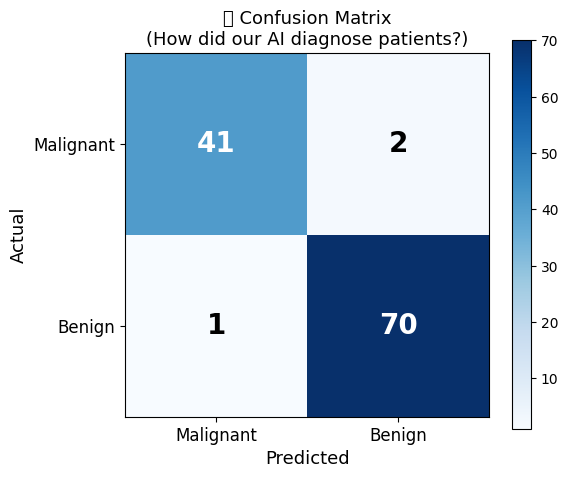


✅ True Positives (Benign correctly identified) : 70
✅ True Negatives (Malignant correctly identified): 41
❌ False Positives (Benign misdiagnosed as Malignant): 2
❌ False Negatives (Malignant missed!) : 1  ← MOST DANGEROUS!


In [ ]:
# ── Confusion Matrix — What Did the Network Actually Get Wrong? ───────────────
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks([0,1]); ax.set_xticklabels(['Malignant', 'Benign'], fontsize=12)
ax.set_yticks([0,1]); ax.set_yticklabels(['Malignant', 'Benign'], fontsize=12)
ax.set_xlabel('Predicted', fontsize=13)
ax.set_ylabel('Actual', fontsize=13)
ax.set_title('🩺 Confusion Matrix\n(How did our AI diagnose patients?)', fontsize=13)

for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                fontsize=20, fontweight='bold',
                color='white' if cm[i,j] > cm.max()/2 else 'black')

plt.colorbar(im)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'\n✅ True Positives (Benign correctly identified) : {tp}')
print(f'✅ True Negatives (Malignant correctly identified): {tn}')
print(f'❌ False Positives (Benign misdiagnosed as Malignant): {fp}')
print(f'❌ False Negatives (Malignant missed!) : {fn}  ← MOST DANGEROUS!')

---
## 📝 SUMMARY — Day 2 Key Takeaways

| Concept | What We Learned | Best Practice |
|---|---|---|
| **Optimiser** | Controls how we descend the loss mountain | Use **Adam** with lr=0.001 |
| **Initialisation** | Where weights start matters greatly | Use **He** (default) — never all zeros |
| **Regularisation** | Prevents memorisation | Use **L2 + Early Stopping** |
| **Scaling** | Makes all features comparable | Always **StandardScaler** before training |
| **Train/Test split** | Fair evaluation on unseen data | 80/20 with fixed random seed |

---

## 🎯 Mini Challenge (Try Yourself!)

1. Change `hidden_layer_sizes` to `(128, 64, 32)` — does it improve accuracy?
2. Change `alpha` from `0.01` to `1.0` — what happens?
3. Change `solver='adam'` to `solver='sgd'` — compare results!

---

> 🔜 **Day 3 Preview:** Convolutional Neural Networks (CNNs) — how AI sees images!

---
*Masterclass — Day 2 | 1st April 2026 | Breast Cancer Deep Learning Session*